In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler


In [40]:
iris = pd.read_csv("/content/iris.csv")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [41]:
class LinearSVWUsingSoftmargin:
    def __init__(self, C=1.0):
      self._support_vectors = None
      self.C = C
      self.beta = None
      self.b = None
      self.X = None
      self.y = None

      self.n = 0
      self.d = 0
    def __decision_function(self,X):
      return X.dot(self.beta) + self.b

    def __cost(self, margin) :
      return (1 / 2) * self.beta.dot(self.beta) + self.C * np.sum(np.maximum(0,1 -margin))

    def __margin(self,X,y):
      return y * self.__decision_function(X)

    def fit(self,X,y, lr=1e-3,epochs=500):
      self.n,self.d = X.shape
      self.beta = np.random.randn(self.d)
      self.b =0

      self.X = X
      self.y = y

      loss_array = []
      for _ in range(epochs):
          margin = self.__margin(X,y)

          misclassified_pts_idx = np.where(margin < 1)[0]

          d_beta = self.beta - self.C * y[misclassified_pts_idx].dot(X[misclassified_pts_idx])
          self.beta = self.beta - lr * d_beta

          d_b = -self.C * np.sum(y[misclassfied_pts_index])
          self.b = self.b - lr * d_b

          loss = self.__cost(margin)
          loss_array.append(loss)
      self._support_vectors = np.where(self.__margin(X,y)<=1)[0]

    def predict(self,X):
        return np.sign(self.__decision_function(X))

    def score(self,X,y):
        P = self.predict(X)
        return np.mean(y==P)

    def plot_decision_boundary(self):
        plt.scatter(self.X[:,1], c=self.y, s=50, cmap=plt.cm.Paired, alpha=.7)
        ax = plt.gca()
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()

        xx = np.linspace(xlim[0],xlim[1],30)
        yy = np.linspace(ylim[0],ylim[1],30)
        YY,XX = np.meshgrid(yy,xx)
        xy = np.vstack([XX.ravel(),YY.ravel()]).T
        Z = self.__decision_function(xy).reshape(XX.shape)

        ax.contour(XX,YY,Z,colors=['r','b','g'],levels = [-1,0,1], alpha=0.5,
             linestyles = ['--','-','--'],linewidths = [2.0,2.0,2.0])

        ax.scatter(self.X[:,0][self._support_vectors],self.X[:,1][self._support_vectors],s-100,
                   linewidth=1,facecolors='none',edgecolors='k')

        def load_data(cols):
          iris = sns.load_dataset("iris")
          iris = iris.tail(100)

          le = preprocessing.LabelEncoder()
          y = le.fit_transform(iris["species"])

          x = iris.drop(["species"],axis=1)

        if len(cols)>0:
            X = X[cols]

            return X.values,y


        if __name__ =='__main__':
          cols = ["sepal_length","sepal_width"]
          X,y = load_data(cols)

          y[y == 0] = -1

          scaler = StandardScaler()
          X = scaler.fit_transform(X)
          model = LinearSVMUsingSoftMargin(C=15.0)

          model.fit(X,y)
          print("train score:" , model.score(X,y))

          model.plot_decision_boundary()
          plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

Train score: 0.6666666666666666


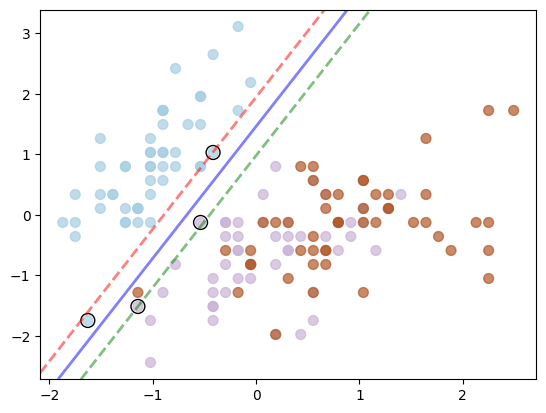

In [42]:

class LinearSVMUsingSoftMargin:
    def __init__(self, C=1.0):
        self._support_vectors = None
        self.C = C
        self.beta = None
        self.b = None
        self.X = None
        self.y = None
        self.n = 0
        self.d = 0

    def __decision_function(self, X):
        return X.dot(self.beta) + self.b

    def __cost(self, margin):
        return (1 / 2) * self.beta.dot(self.beta) + self.C * np.sum(np.maximum(0, 1 - margin))

    def __margin(self, X, y):
        return y * self.__decision_function(X)

    def fit(self, X, y, lr=1e-3, epochs=500):
        self.n, self.d = X.shape
        self.beta = np.random.randn(self.d)
        self.b = 0
        self.X = X
        self.y = y

        loss_array = []
        for _ in range(epochs):
            margin = self.__margin(X, y)
            misclassified_pts_idx = np.where(margin < 1)[0]

            d_beta = self.beta - self.C * y[misclassified_pts_idx].dot(X[misclassified_pts_idx])
            self.beta = self.beta - lr * d_beta

            d_b = -self.C * np.sum(y[misclassified_pts_idx])
            self.b = self.b - lr * d_b

            loss = self.__cost(margin)
            loss_array.append(loss)

        self._support_vectors = np.where(self.__margin(X, y) <= 1)[0]

    def predict(self, X):
        return np.sign(self.__decision_function(X))

    def score(self, X, y):
        P = self.predict(X)
        return np.mean(y == P)

    def plot_decision_boundary(self):
        plt.scatter(self.X[:, 0], self.X[:, 1], c=self.y, s=50, cmap=plt.cm.Paired, alpha=.7)
        ax = plt.gca()
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()

        xx = np.linspace(xlim[0], xlim[1], 30)
        yy = np.linspace(ylim[0], ylim[1], 30)
        YY, XX = np.meshgrid(yy, xx)
        xy = np.vstack([XX.ravel(), YY.ravel()]).T
        Z = self.__decision_function(xy).reshape(XX.shape)

        ax.contour(XX, YY, Z, colors=['r', 'b', 'g'], levels=[-1, 0, 1], alpha=0.5,
                   linestyles=['--', '-', '--'], linewidths=[2.0, 2.0, 2.0])

        ax.scatter(self.X[:, 0][self._support_vectors], self.X[:, 1][self._support_vectors], s=100,
                   linewidth=1, facecolors='none', edgecolors='k')

# Load data from iris.csv
def load_data_from_csv(file_path, cols):
    # Read the iris dataset from the CSV file
    iris = pd.read_csv(file_path)

    # Extract the feature columns and target column
    X = iris[cols].values
    y = iris["species"].values

    # Convert target labels to numeric (Label encoding)
    le = preprocessing.LabelEncoder()
    y = le.fit_transform(y)

    return X, y

if __name__ == '__main__':
    # Path to your iris.csv file
    file_path = '/content/iris.csv'  # Update this with the correct path to your iris.csv

    # Select the columns to use for training
    cols = ["sepal_length", "sepal_width"]

    # Load data from CSV
    X, y = load_data_from_csv(file_path, cols)

    # Change labels to -1 and 1 for binary classification
    y[y == 0] = -1  # Assuming "setosa" class is now -1 (for binary classification)

    # Standardize the features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Initialize and train the model
    model = LinearSVMUsingSoftMargin(C=15.0)
    model.fit(X, y)

    # Print the train score
    print("Train score:", model.score(X, y))

    # Plot the decision boundary
    model.plot_decision_boundary()
    plt.show()
